## Simple implementation of yolo models 

Using YOLO26 latest at this time from a family of yolo models

The intent is not to evaluate the performance of the training algorithm, but the result provided by training with synthetical images, so just a simple Yolo Training and Evaluation pipeline, with similar tuning for both synthetic and real images will be created.

Need to create 3 x 2 sets of images

Training, Validation and Test  for both real and synthetic 
Need to show some graphs displaying the size of both sets 

Then the training, evaluation and and at the end test

Actually the synthetic subset does not need a test set. because both sets will be evaluated against the real test sub set


In [1]:
!pip install ultralytics


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import math
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
%matplotlib inline
from ultralytics import YOLO
from PIL import Image
import matplotlib.image as mpimg

import torch
print(torch.cuda.is_available()) # Cuda availability will improve the training speed of the models 

True


## Model Training

In [2]:
# Training constants 

MODEL = "yolo26n.yaml"
EPOCHS_N = 100          # Total training iterations
EARLY_STOP_N = 20       # Early stopping: stop if no improvement for 20 epochs
DEVICE = 0              # Use GPU (device=0) or 'cpu'
IMG_SIZE = 640          # Image size

In [3]:
def print_metric_descriptions(verbose=True):
    
    # Define the metric data structurally
    metrics_data = {
        "Training Progress (Losses)": [
            {"name": "box_loss", "goal": "[Lower Better]", "desc": "Accuracy of bounding box placement."},
            {"name": "cls_loss", "goal": "[Lower Better]", "desc": "Accuracy of object classification."},
            {"name": "dfl_loss", "goal": "[Lower Better]", "desc": "Distribution Focal Loss (refines box edges)."},
            {"name": "GPU_mem",  "goal": "[Resource Use]", "desc": "VRAM used during this epoch."}
        ],
        "Validation Metrics": [
            {"name": "Precision (P)", "goal": "[Higher Better]", "desc": "Percentage of detections that are correct."},
            {"name": "Recall (R)",    "goal": "[Higher Better]", "desc": "Percentage of real objects actually found."},
            {"name": "mAP50",         "goal": "[Higher Better]", "desc": "Accuracy at 0.50 Intersection over Union (IoU)."},
            {"name": "mAP50-95",      "goal": "[Higher Better]", "desc": "Comprehensive accuracy across all IoU thresholds."}
        ]
    }

    if verbose:
        print("\n=== YOLO TRAINING METRICS DICTIONARY ===")
        print(f"{'Metric Name':<20} | {'Goal':<15} | {'Description'}")
        print("-" * 90)

        for section, metrics in metrics_data.items():
            print(f"\n--- {section} ---")
            for m in metrics:
                print(f"{m['name']:<20} | {m['goal']:<15} | {m['desc']}")
        print("-" * 90)

In [4]:
def Training(data, projectName, trainingSaveName):
    model = YOLO(MODEL)
    results = model.train(
        data          = data,
        epochs        = EPOCHS_N,
        patience      = EARLY_STOP_N,
        imgsz         = IMG_SIZE,
        device        = DEVICE,
        save          = True,
        project       = projectName,
        name          = trainingSaveName,
        exist_ok      = True,
    )

    train_img_path = os.path.join(results.save_dir, "results.png")

    print("\n=== TRAINING RESULTS ===")
    if os.path.exists(train_img_path):
        fig, ax = plt.subplots(figsize=(16, 8))
        ax.imshow(mpimg.imread(train_img_path))
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("results.png not found in training directory.")

    return model
def _show_images(paths, ncols=2, figsize_per=(10, 6)):
    existing = [p for p in paths if os.path.exists(p)]
    missing  = [p for p in paths if not os.path.exists(p)]

    for p in missing:
        print(f"Skipping (not found): {os.path.basename(p)}")

    if not existing:
        return

    nrows = math.ceil(len(existing) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows),
        dpi=100,
    )
    axes = axes.flatten() if nrows * ncols > 1 else [axes]

    for ax, path in zip(axes, existing):
        ax.imshow(mpimg.imread(path))
        ax.set_title(os.path.basename(path), fontsize=10)
        ax.axis('off')

    for ax in axes[len(existing):]:
        ax.set_visible(False)

    plt.tight_layout()
    
    # Force inline rendering regardless of backend
    from IPython.display import display
    display(fig)
    plt.close(fig)

def Validation(model, data, split = 'val'):
    print("\nRunning Validation...")
    metrics = model.val(data = data, split = split)

    print("\n=== PERFORMANCE SUMMARY ===")
    print(f"Overall Fitness : {metrics.box.fitness():.4f}")
    print(f"Mean Precision  : {metrics.box.mp:.4f}")
    print(f"Mean Recall     : {metrics.box.mr:.4f}")
    print(f"mAP50           : {metrics.box.map50:.4f}")
    print(f"mAP50-95        : {metrics.box.map:.4f}")
    #print(f"Best checkpoint : {model.trainer.best}")

    val_dir = metrics.save_dir
    image_names = [
        "confusion_matrix.png",
        "confusion_matrix_normalized.png",
        "BoxF1_curve.png",
        "BoxP_curve.png",
        "BoxR_curve.png",
        "BoxPR_curve.png",
        "val_batch2_labels.jpg",
        "val_batch2_pred.jpg",
    ]

    print("\n=== VALIDATION PLOTS ===")
    _show_images([os.path.join(val_dir, name) for name in image_names])


=== YOLO TRAINING METRICS DICTIONARY ===
Metric Name          | Goal            | Description
------------------------------------------------------------------------------------------

--- Training Progress (Losses) ---
box_loss             | [Lower Better]  | Accuracy of bounding box placement.
cls_loss             | [Lower Better]  | Accuracy of object classification.
dfl_loss             | [Lower Better]  | Distribution Focal Loss (refines box edges).
GPU_mem              | [Resource Use]  | VRAM used during this epoch.

--- Validation Metrics ---
Precision (P)        | [Higher Better] | Percentage of detections that are correct.
Recall (R)           | [Higher Better] | Percentage of real objects actually found.
mAP50                | [Higher Better] | Accuracy at 0.50 Intersection over Union (IoU).
mAP50-95             | [Higher Better] | Comprehensive accuracy across all IoU thresholds.
------------------------------------------------------------------------------------------
Ne

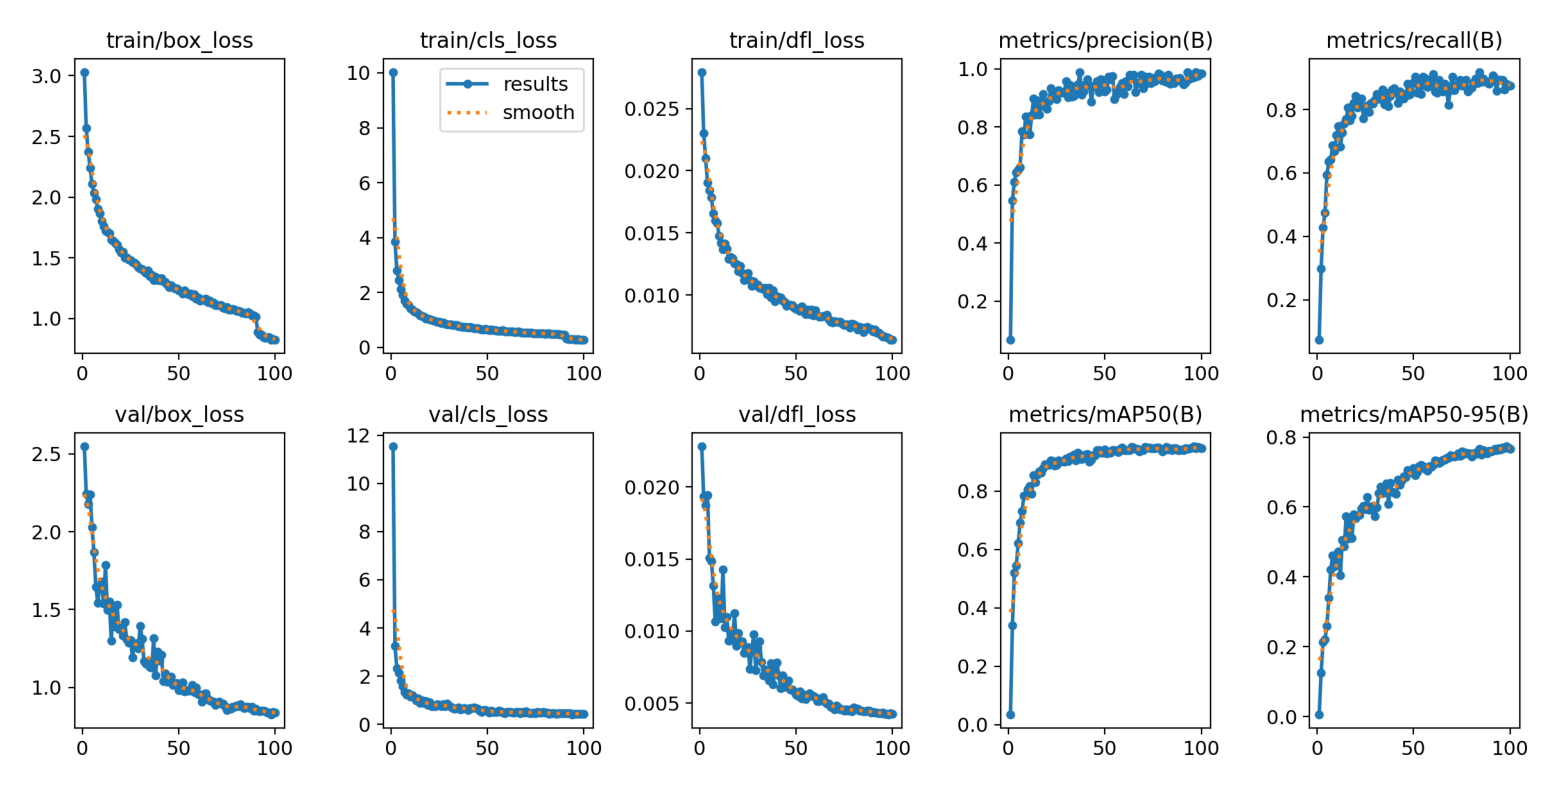

In [6]:
print_metric_descriptions()

model = Training("./Datasets/YOLO_Datasets/Final/dataset.yaml", "SHOE" , "SYNTH")


Running Validation...
Ultralytics 8.4.66  Python-3.13.0 torch-2.12.0+cu132 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16302MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 324.6115.5 MB/s, size: 53.1 KB)
val: Scanning F:\PPG\Datasets\YOLO_Datasets\Final\val\labels.cache... 253 images, 37 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 253/253 88.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.8it/s 2.4s0.1s
                   all        253        217       0.97      0.882       0.95      0.771
Speed: 1.7ms preprocess, 2.8ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to F:\PPG\runs\detect\val

=== PERFORMANCE SUMMARY ===
Overall Fitness : 0.7712
Mean Precision  : 0.9696
Mean Recall     : 0.8818
mAP50           : 0.9503
mAP50-95        : 0.7712
Best checkpoint : F:\PPG\runs\detect\SHOE\Synth\weights\best.pt

=== 

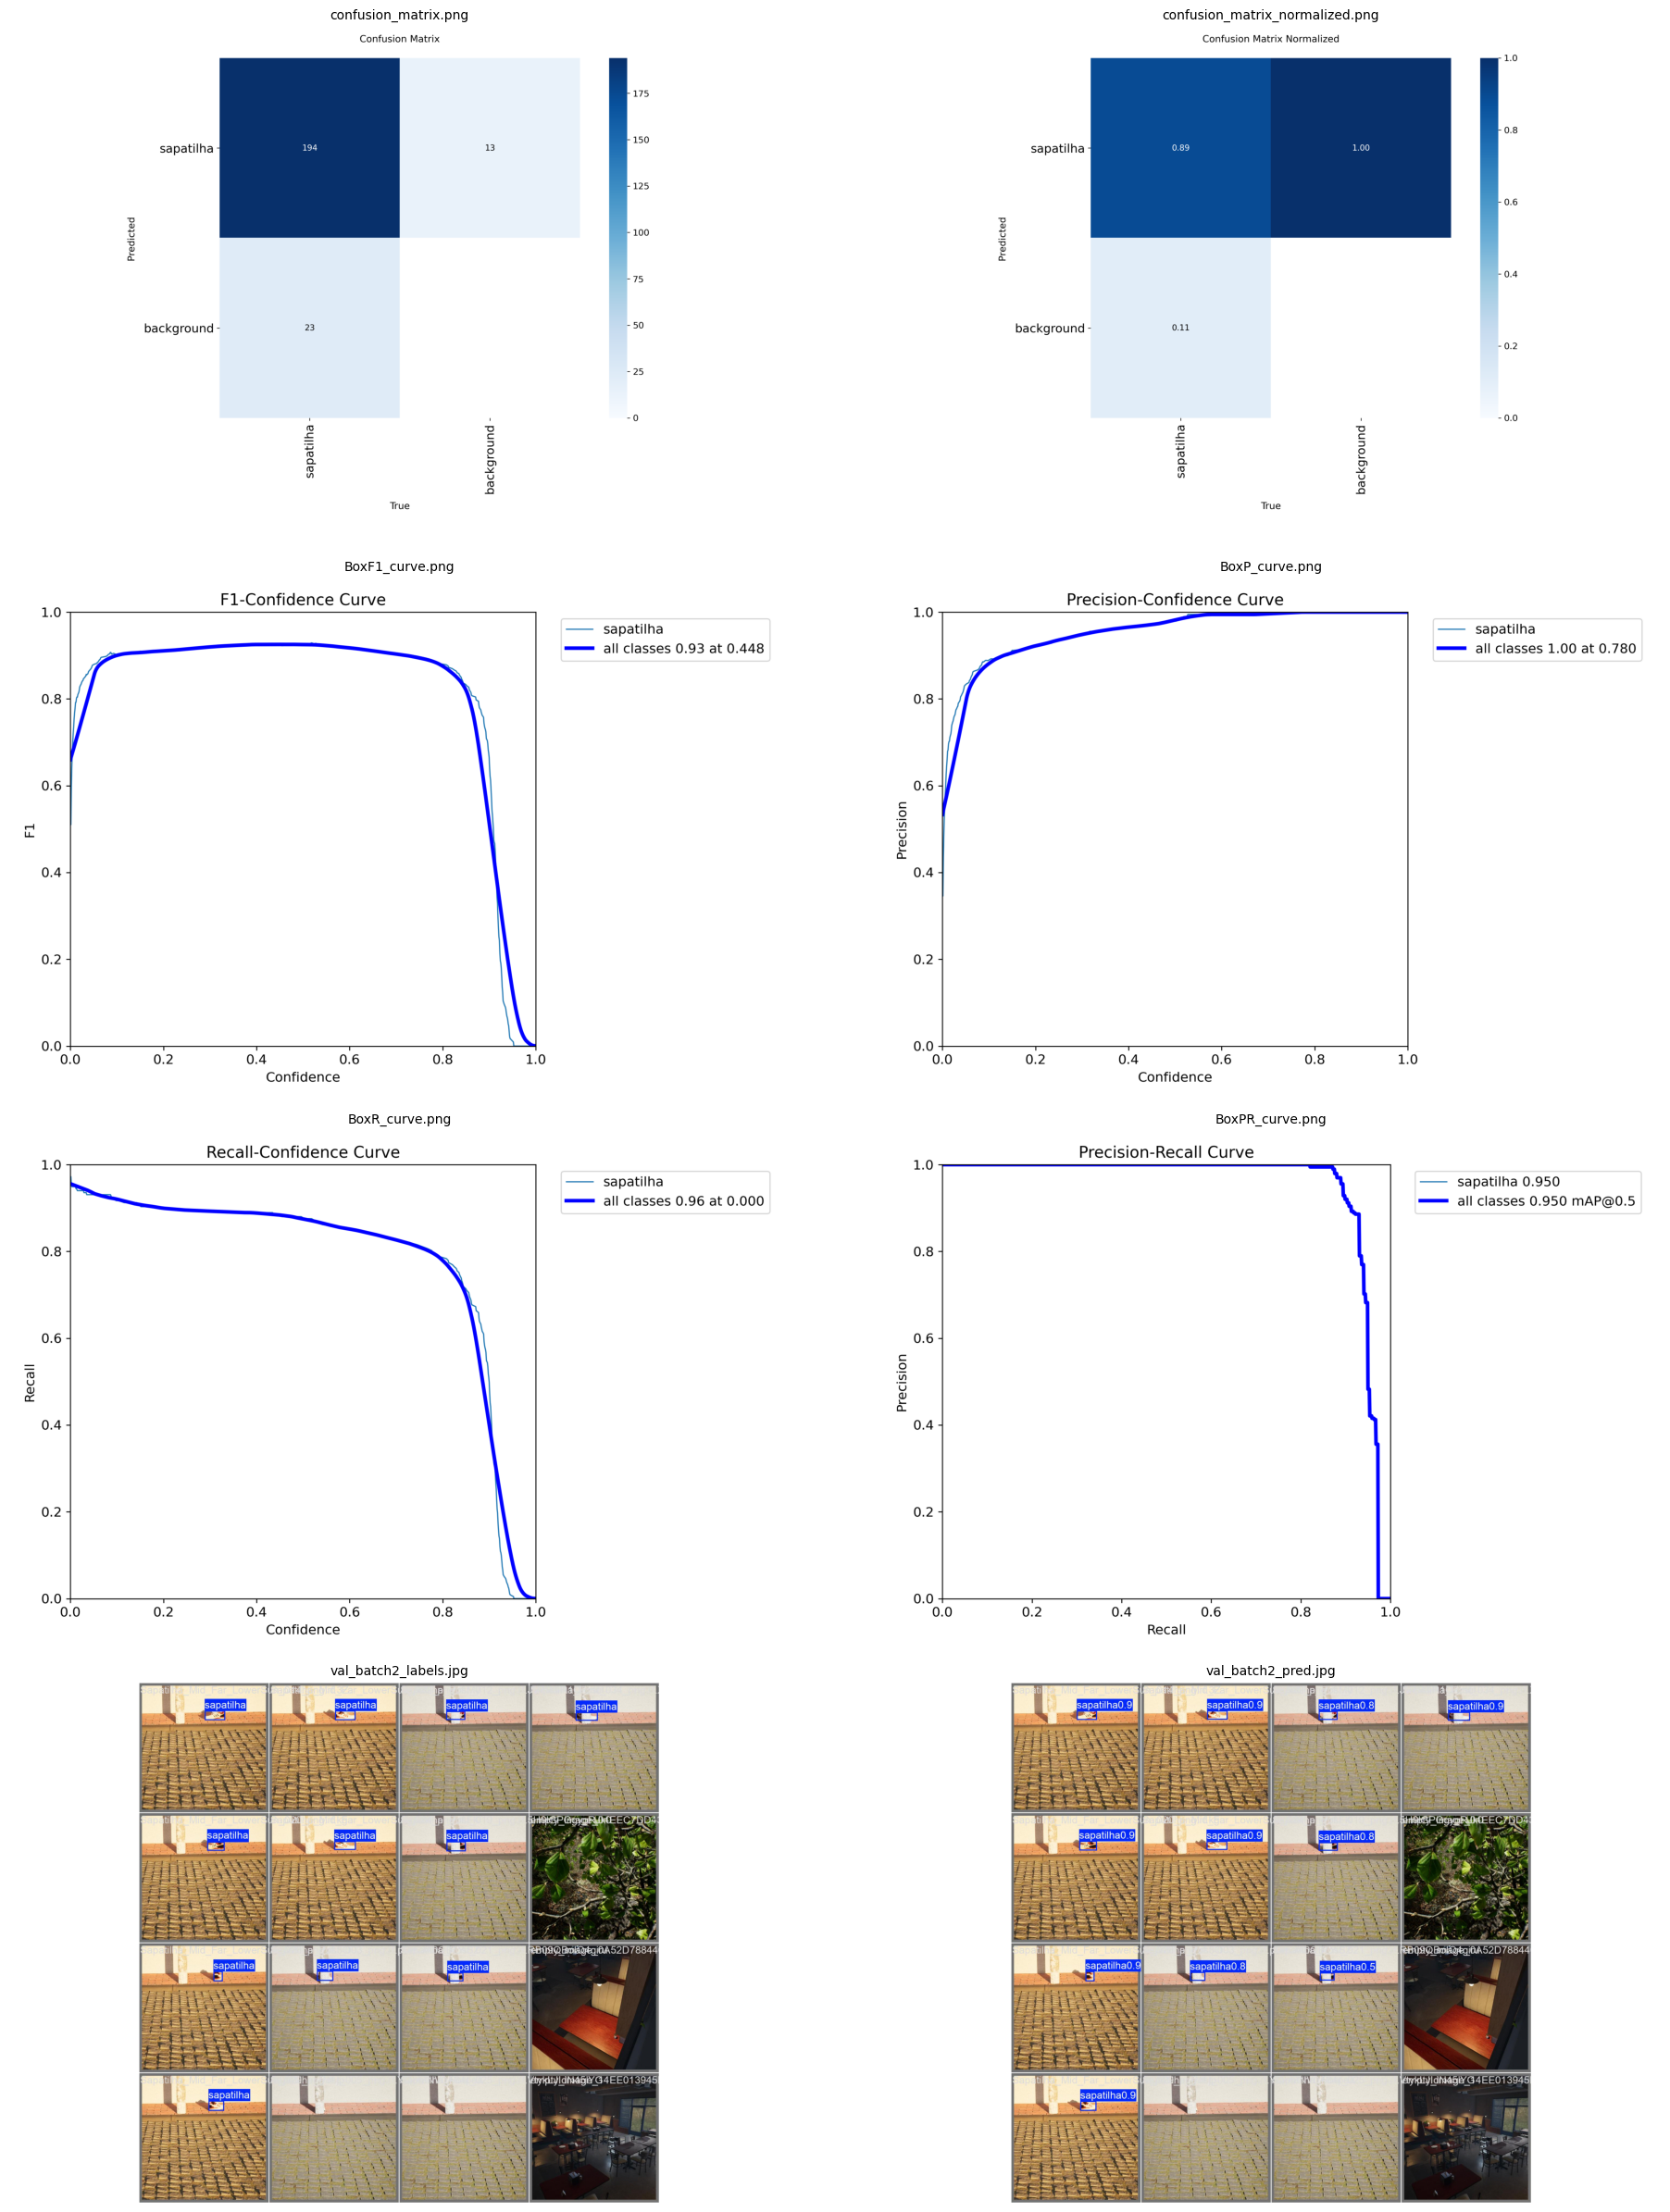

In [ ]:
Validation(model, data = "./Datasets/YOLO_Datasets/Final/dataset.yaml")

### Training dataset with real images


=== YOLO TRAINING METRICS DICTIONARY ===
Metric Name          | Goal            | Description
------------------------------------------------------------------------------------------

--- Training Progress (Losses) ---
box_loss             | [Lower Better]  | Accuracy of bounding box placement.
cls_loss             | [Lower Better]  | Accuracy of object classification.
dfl_loss             | [Lower Better]  | Distribution Focal Loss (refines box edges).
GPU_mem              | [Resource Use]  | VRAM used during this epoch.

--- Validation Metrics ---
Precision (P)        | [Higher Better] | Percentage of detections that are correct.
Recall (R)           | [Higher Better] | Percentage of real objects actually found.
mAP50                | [Higher Better] | Accuracy at 0.50 Intersection over Union (IoU).
mAP50-95             | [Higher Better] | Comprehensive accuracy across all IoU thresholds.
------------------------------------------------------------------------------------------
Ne

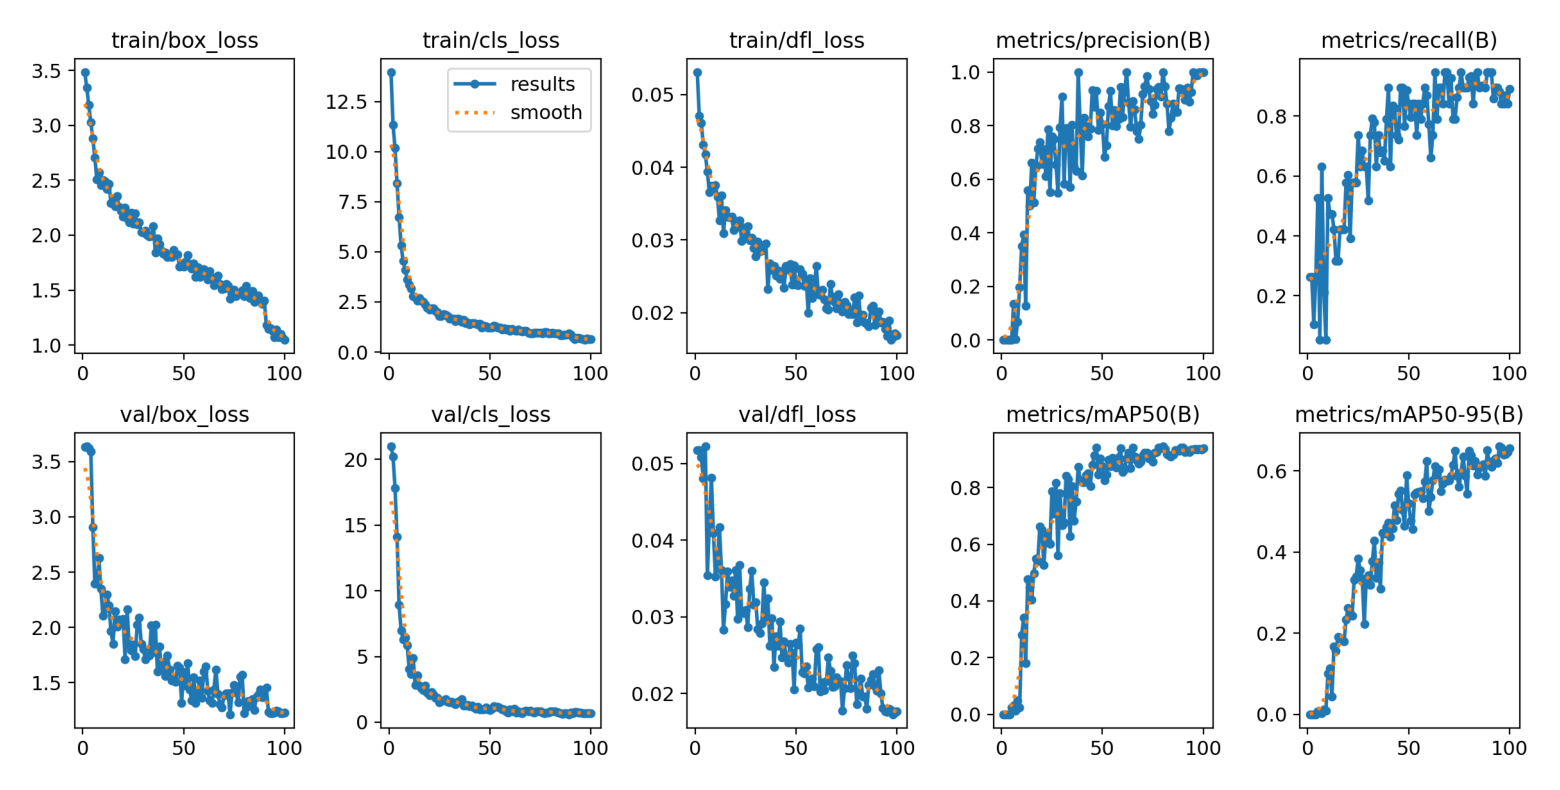

In [5]:
print_metric_descriptions()

model_real = Training("./Datasets/YOLO_Datasets/Real/dataset.yaml", "SHOE" , "REAL")


Running Validation...
Ultralytics 8.4.66  Python-3.13.0 torch-2.12.0+cu132 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16302MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 419.7128.2 MB/s, size: 97.7 KB)
val: Scanning F:\PPG\Datasets\YOLO_Datasets\Real\val\labels.cache... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 7.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.8s/it 3.7s<11.4s
                   all         19         19          1      0.882      0.934       0.66
Speed: 6.6ms preprocess, 17.0ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to F:\PPG\runs\detect\val-7

=== PERFORMANCE SUMMARY ===
Overall Fitness : 0.6600
Mean Precision  : 1.0000
Mean Recall     : 0.8818
mAP50           : 0.9341
mAP50-95        : 0.6600

=== VALIDATION PLOTS ===
Skipping (not found): val_batch2_labels.jpg
Sk

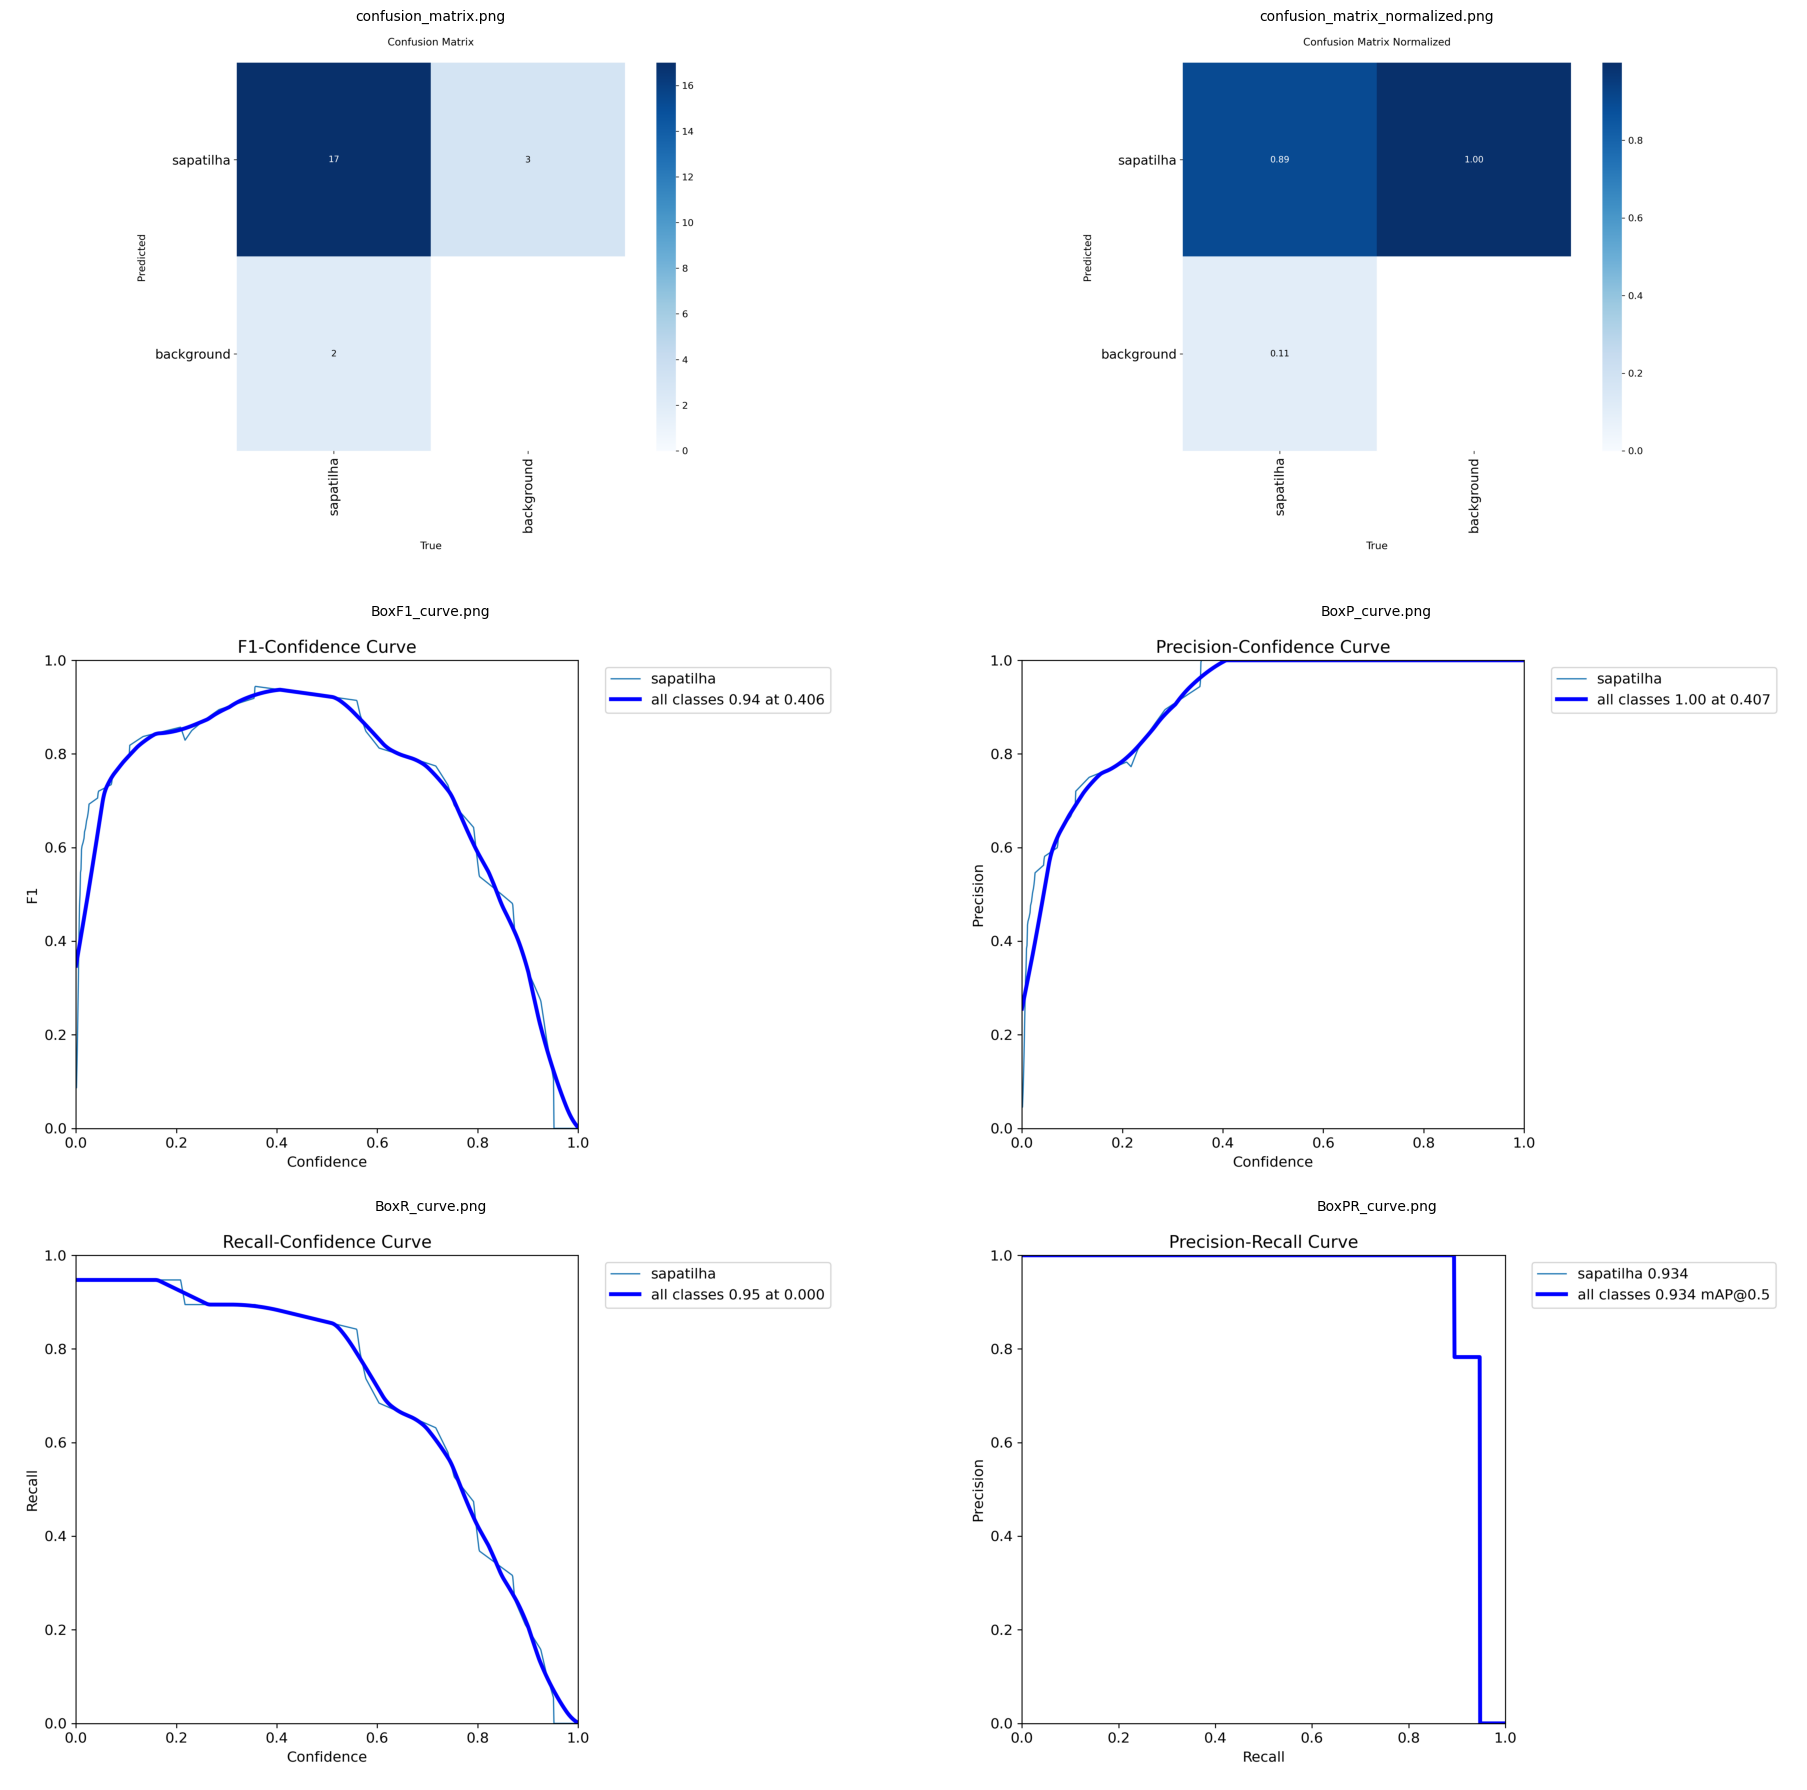

In [7]:
Validation(model_real, data = "./Datasets/YOLO_Datasets/Real/dataset.yaml")

### Loading the model from file and comparing results


Running Validation...
Ultralytics 8.4.66  Python-3.13.0 torch-2.12.0+cu132 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16302MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 809.1113.5 MB/s, size: 119.6 KB)
val: Scanning F:\PPG\Datasets\YOLO_Datasets\Real\test\labels.cache... 20 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 5.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4s/it 2.9s9.2s
                   all         20         19      0.868      0.789      0.779      0.565
Speed: 2.1ms preprocess, 3.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to F:\PPG\runs\detect\val

=== PERFORMANCE SUMMARY ===
Overall Fitness : 0.5647
Mean Precision  : 0.8684
Mean Recall     : 0.7895
mAP50           : 0.7792
mAP50-95        : 0.5647

=== VALIDATION PLOTS ===
Skipping (not found): val_batch2_labels.jpg
Skipp

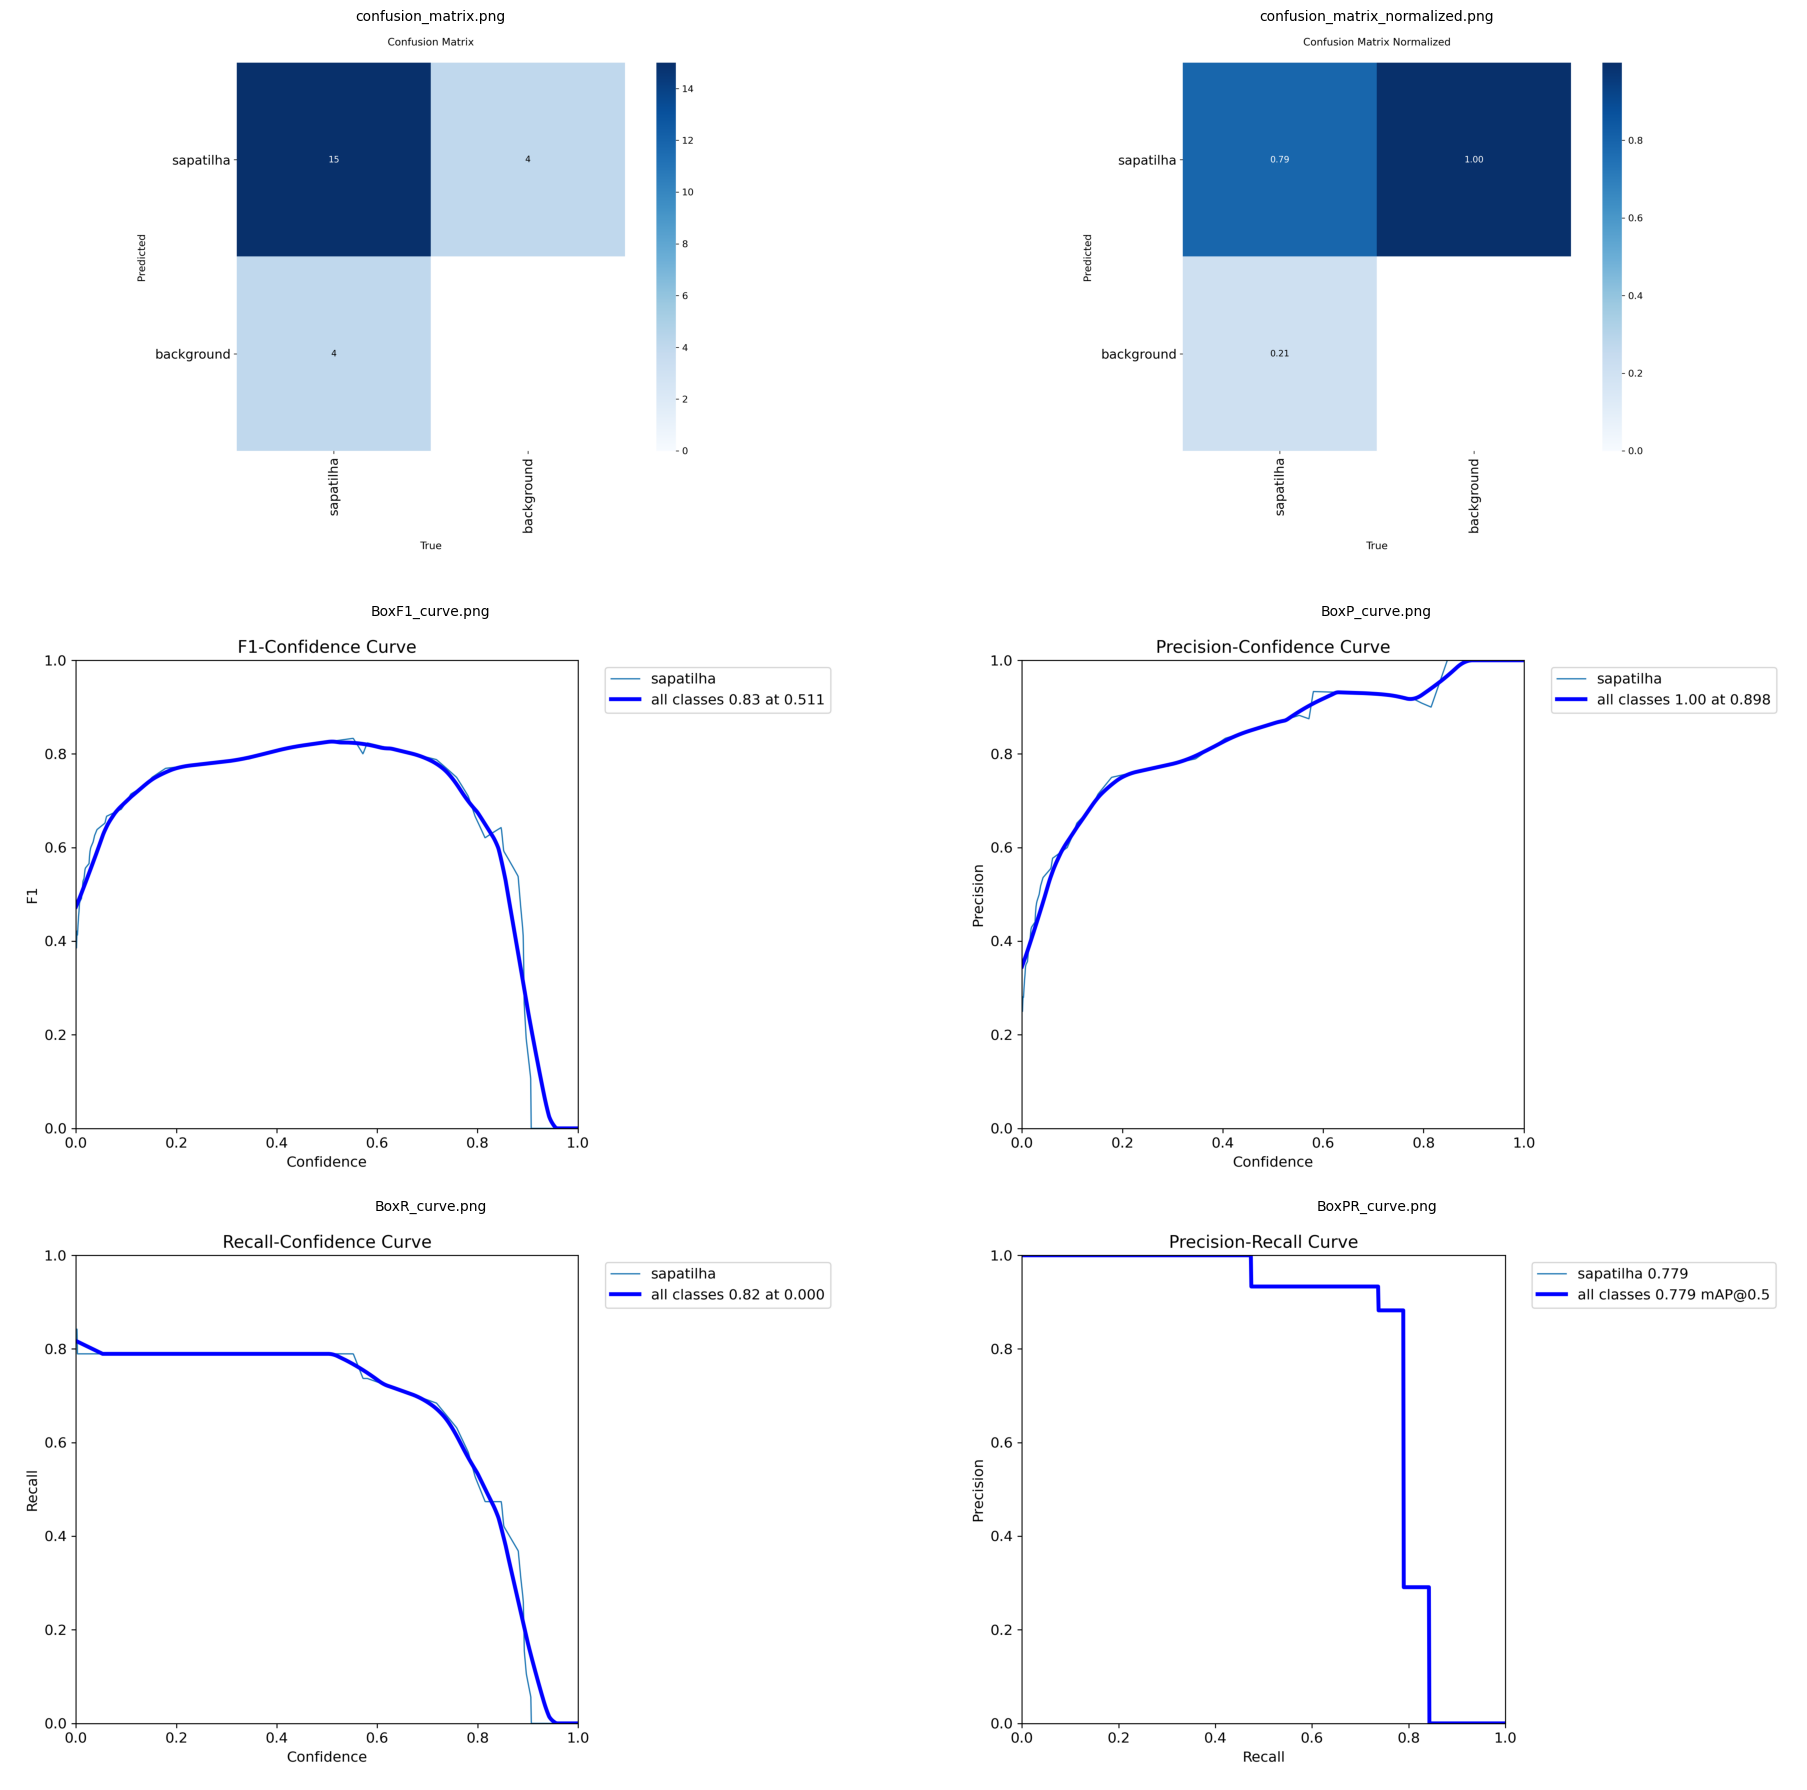


Running Validation...
Ultralytics 8.4.66  Python-3.13.0 torch-2.12.0+cu132 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16302MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 637.874.9 MB/s, size: 104.8 KB)
val: Scanning F:\PPG\Datasets\YOLO_Datasets\Real\test\labels.cache... 20 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 7.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.5s/it 3.1s<10.0s
                   all         20         19      0.795      0.737      0.831      0.516
Speed: 3.0ms preprocess, 11.7ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to F:\PPG\runs\detect\val-2

=== PERFORMANCE SUMMARY ===
Overall Fitness : 0.5158
Mean Precision  : 0.7953
Mean Recall     : 0.7368
mAP50           : 0.8310
mAP50-95        : 0.5158

=== VALIDATION PLOTS ===
Skipping (not found): val_batch2_labels.jpg
S

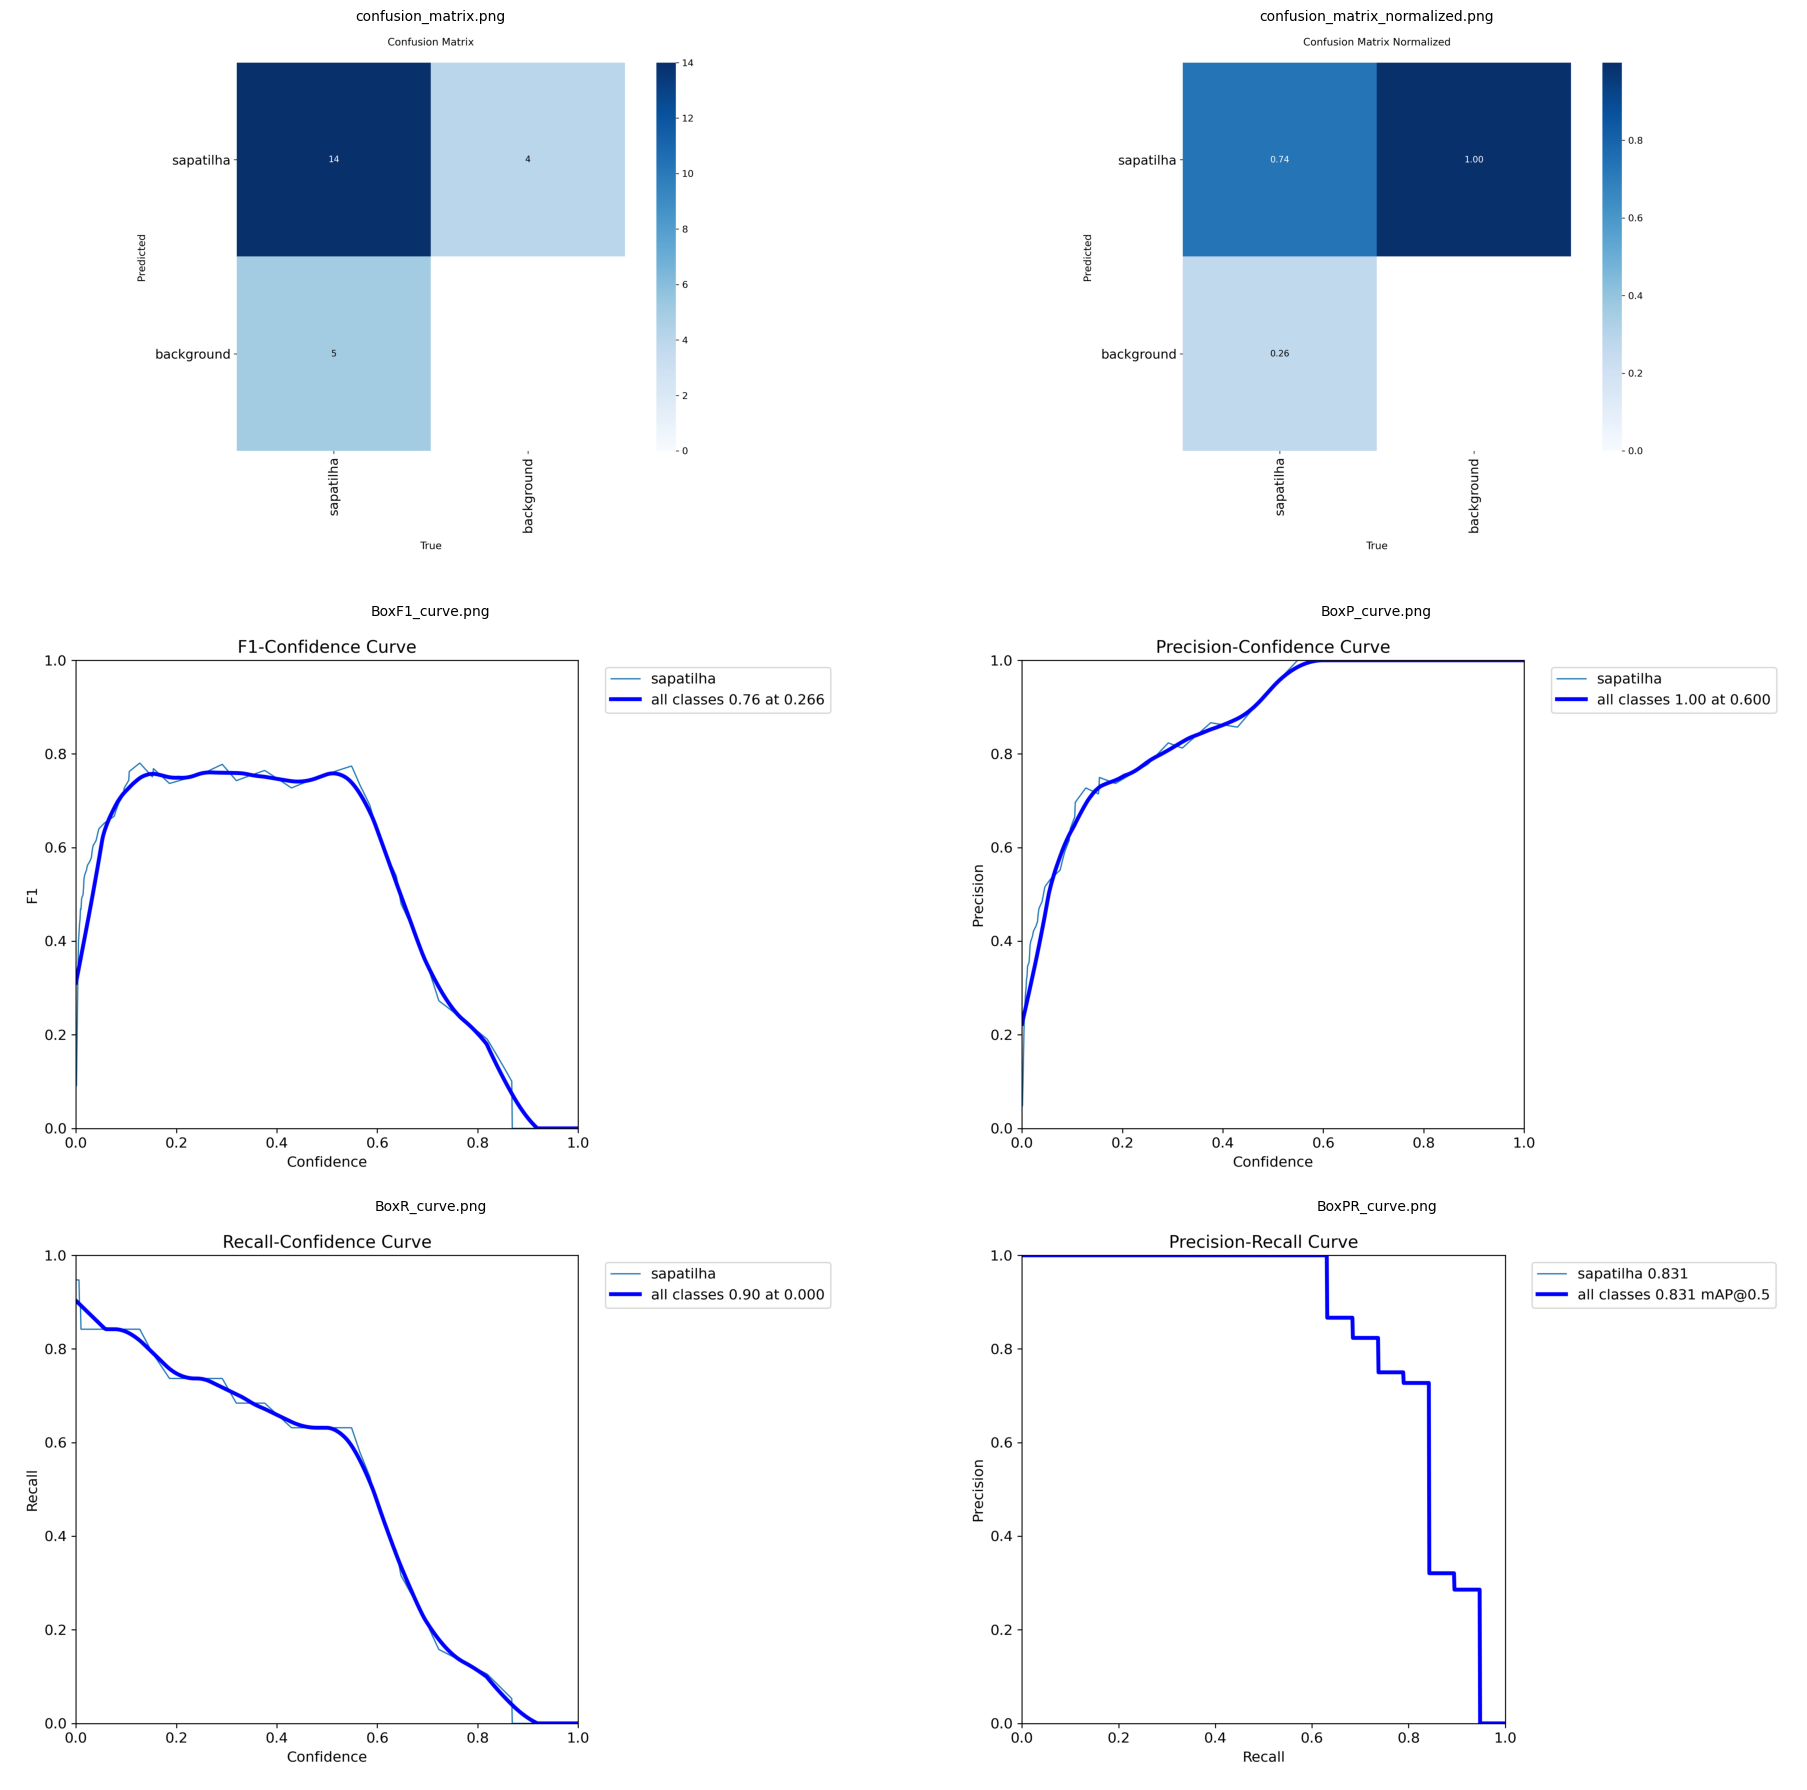

In [9]:
model_synth =  YOLO("./runs/detect/SHOE/Synth/weights/best.pt")
model_real =  YOLO("./runs/detect/SHOE/REAL/weights/best.pt")

# In both models the test is loaded with the same images

# 2. Run evaluation on the 'test' split
# Ensure your data.yaml has a 'test' path defined
Validation(model_synth, data = './Datasets/YOLO_Datasets/Real/dataset.yaml', split = 'test')


Validation(model_real, data = './Datasets/YOLO_Datasets/Real/dataset.yaml', split = 'test')